In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [87]:
df_boston=pd.read_csv("/content/boston.csv")

In [88]:
df_boston.shape

(506, 15)

In [89]:
df_boston.head()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [90]:
df_boston.columns

Index(['Unnamed: 0', 'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
       'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'PRICE'],
      dtype='object')

In [91]:
df_boston.isna().sum()

,0
Unnamed: 0,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0


In [92]:
df_boston.duplicated().sum()

np.int64(0)

In [93]:
clean_df = df_boston.drop(columns=["Unnamed: 0"])

The `df_boston` DataFrame contains the following columns, which represent different features of housing in Boston:

*   **Unnamed: 0**: This column appears to be an unneeded index column from the CSV file and can likely be dropped.
*   **CRIM**: Per capita crime rate by town.
*   **ZN**: Proportion of residential land zoned for lots over 25,000 sq.ft.
*   **INDUS**: Proportion of non-retail business acres per town.
*   **CHAS**: Charles River dummy variable (1 if tract bounds river; 0 otherwise).
*   **NOX**: Nitric oxides concentration (parts per 10 million).
*   **RM**: Average number of rooms per dwelling.
*   **AGE**: Proportion of owner-occupied units built prior to 1940.
*   **DIS**: Weighted distances to five Boston employment centres.
*   **RAD**: Index of accessibility to radial highways.
*   **TAX**: Full-value property-tax rate per $10,000.
*   **PTRATIO**: Pupil-teacher ratio by town.
*   **B**: 1000(Bk - 0.63)^2 where Bk is the proportion of Black residents by town.
*   **LSTAT**: % lower status of the population.
*   **PRICE**: Median value of owner-occupied homes in $1000s (This is often the target variable).

In [94]:
clean_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [95]:
bar=px.scatter(clean_df,x="CRIM", y="PRICE",trendline="lowess",opacity=0.3,labels={
    "CRIM":"PER CAPITA CRIME RATE PER TOWN",
    "PRICE":"PRICE OF PROPERTY"
})
bar.update_traces(line=dict(color="black", width=3), selector=dict(mode="lines"))

In [96]:
bar=px.scatter(clean_df,x="AGE", y="PRICE",trendline="lowess",opacity=0.3,labels={
    "AGE":" Proportion of owner-occupied units built prior to 1940",
    "PRICE":"Price of property"
})
bar.update_traces(line=dict(color="black", width=3), selector=dict(mode="lines"))

In [97]:
bar=px.scatter(clean_df,x="TAX", y="PRICE",trendline="lowess",opacity=0.3,labels={
    "TAX":"Full-value property tax rate per 10,000 USD ",
    "PRICE":"Price of property"
})
bar.update_traces(line=dict(color="black", width=3), selector=dict(mode="lines"))

In [98]:
clean_df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [99]:
X=clean_df.drop(columns="PRICE")
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [100]:
y=np.log1p(clean_df['PRICE'])


In [101]:
X_transformed = X.copy()
skewed_features = ['CRIM', 'ZN', 'NOX', 'RAD', 'TAX', 'B', 'LSTAT']
for feature in skewed_features:
    X_transformed[feature] = np.log1p(X_transformed[feature])
X_transformed.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.006300,2.944439,2.31,0.0,0.430483,6.575,65.2,4.0900,0.693147,5.693732,15.3,5.986201,1.788421
1,0.026944,0.000000,7.07,0.0,0.384582,6.421,78.9,4.9671,1.098612,5.493061,17.8,5.986201,2.316488
2,0.026924,0.000000,7.07,0.0,0.384582,7.185,61.1,4.9671,1.098612,5.493061,17.8,5.975919,1.615420
3,0.031857,0.000000,2.18,0.0,0.377066,6.998,45.8,6.0622,1.386294,5.407172,18.7,5.980479,1.371181
4,0.066770,0.000000,2.18,0.0,0.377066,7.147,54.2,6.0622,1.386294,5.407172,18.7,5.986201,1.845300


In [102]:
X_train,X_test,y_train,y_test=train_test_split(X_transformed,y,test_size=0.3,random_state=3)#test size = 0.3 means 30% of data used for testing and 70% used for training,
                                                                                #random test is used to ensure we get the same train test data points every time the integer we put in corresponds to a particular order of data points take in

In [103]:
lr=LinearRegression()


In [104]:
lr.fit(X_train,y_train)

LinearRegression()

In [105]:
c=lr.intercept_ #finds c for y=m1x1+m2x2 +......+ c

In [106]:
m=lr.coef_#finds all m vlues

In [107]:
y_pred_train=lr.predict(X_train)#finds predicted prices depending on tested params
y_pred_train

array([2.97378993, 2.25891661, 3.61303882, 3.48995249, 3.24919391,
       3.03874462, 3.76850505, 3.63190937, 2.83691887, 2.84692959,
       3.0623944 , 3.33591697, 2.80730694, 3.0075581 , 3.43003179,
       2.74698864, 3.12429496, 3.29897069, 3.61168001, 3.48936714,
       3.56449505, 3.2943462 , 2.78077774, 3.20642039, 3.44837196,
       3.17301073, 2.56538604, 3.08677676, 3.55104821, 2.7411323 ,
       2.42288982, 3.28991363, 2.8837644 , 2.58941278, 3.94518091,
       3.30889301, 2.72834855, 3.13683852, 3.06387151, 3.78707102,
       3.52082905, 2.97908456, 2.86183967, 3.35362645, 3.03713604,
       3.13858168, 3.33954126, 3.33676368, 3.56246809, 2.85317858,
       3.3873979 , 3.21209651, 2.7125443 , 2.88673078, 2.95654415,
       3.25932054, 3.03458476, 3.17122809, 2.6420311 , 3.12274106,
       2.85455081, 2.68075862, 2.86646446, 3.45426041, 3.05705724,
       2.76177996, 3.07983333, 3.83324212, 2.42466518, 3.45144461,
       3.17650509, 3.08258669, 2.56836058, 3.00121831, 3.02745

Text(0, 0.5, 'Predicted Price of test data')

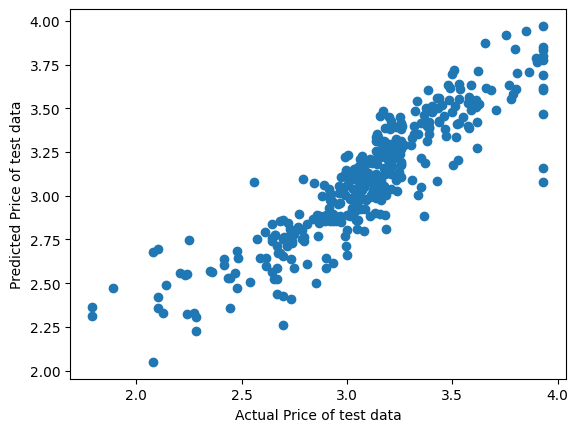

In [108]:
plt.scatter(y_train,y_pred_train) #checks how accurate predicted prices are compared to actual prices
plt.xlabel("Actual Price of test data")
plt.ylabel("Predicted Price of test data")

### Visualizing Feature Distributions Before Transformation

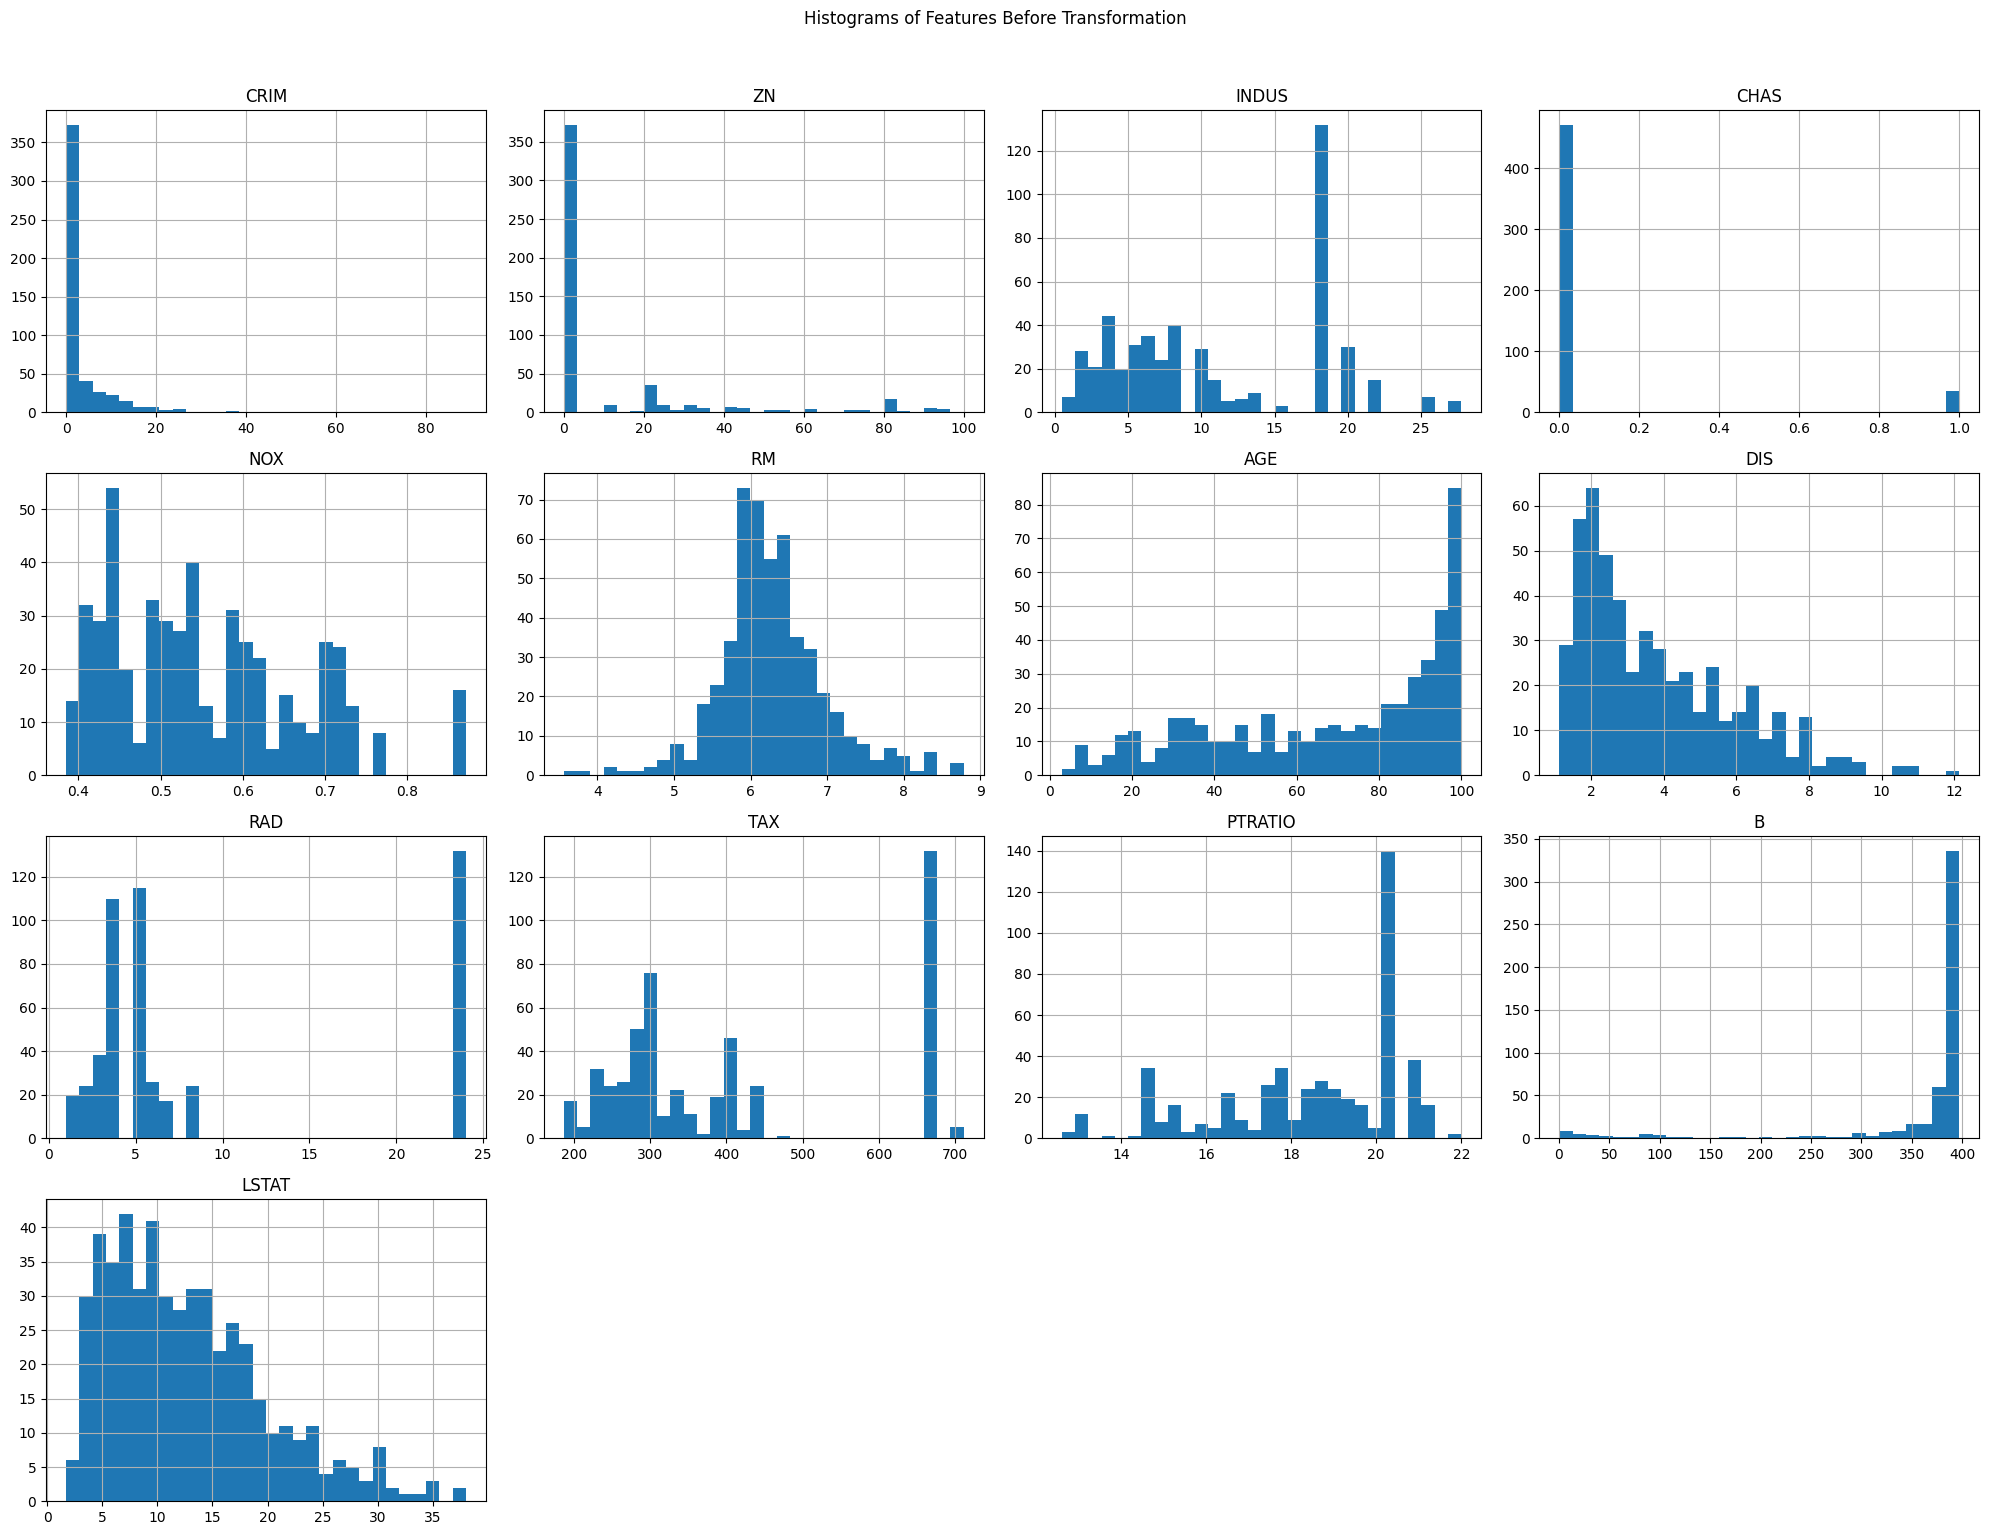

In [109]:
X.hist(bins=30, figsize=(20, 15))
plt.suptitle('Histograms of Features Before Transformation', y=1.02)
plt.tight_layout()
plt.show()

After viewing these histograms, we can identify features that are heavily skewed to the right (e.g., `CRIM`, `ZN`, `NOX`, `RAD`, `TAX`, `B`, `LSTAT`). A log transformation (`np.log1p` is often preferred as it handles zero values by adding 1 before taking the logarithm) can help make these distributions more symmetrical and improve model performance. Features like `CHAS` are binary and `RM`, `AGE`, `DIS`, `PTRATIO` appear more normally distributed or have different characteristics, and might not require log transformation.

Now, let's apply the `np.log1p` transformation to some of the highly skewed features like `CRIM`, `ZN`, `NOX`, `RAD`, `TAX`, `B`, and `LSTAT`. We should also consider transforming the `PRICE` target variable if it's also skewed, but for now, we'll focus on the independent variables.

In [110]:
r2_score(y_train,y_pred_train) #shows how close the values are to the regression line , shows how much the price can be explained by our independent varaibles

0.7999980742010302

Above 0.7 r2 value is good and our r2 value is above 0.7!

In [111]:
y_pred_test=lr.predict(X_test)

Text(0, 0.5, 'Predicted Price of test data')

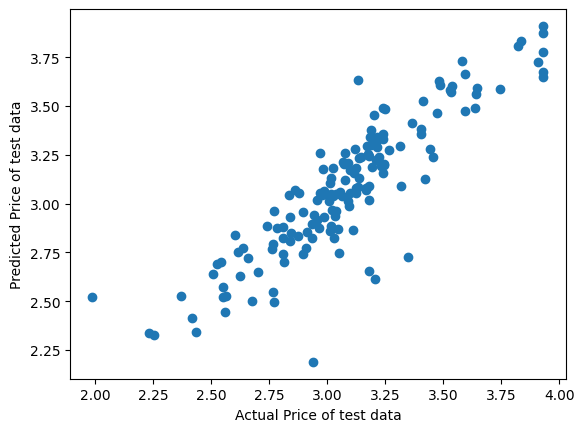

In [114]:
plt.scatter(y_test,y_pred_test) #checks how accurate predicted prices are compared to actual prices
plt.xlabel("Actual Price of test data")
plt.ylabel("Predicted Price of test data")

In [113]:
r2_score(y_test,y_pred_test)

0.7696461245532962

r2 score of testing data seems good too!

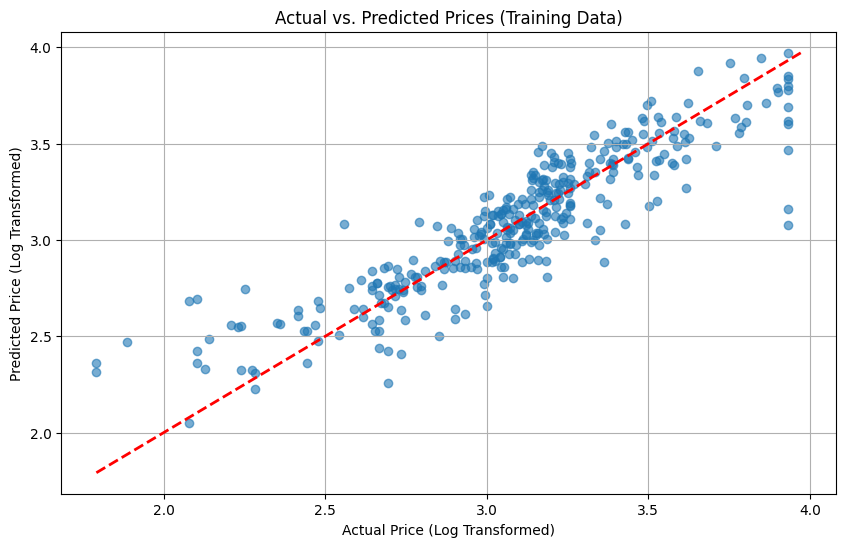

In [116]:
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_pred_train, alpha=0.6)
plt.xlabel('Actual Price (Log Transformed)')
plt.ylabel('Predicted Price (Log Transformed)')
plt.title('Actual vs. Predicted Prices (Training Data)')

# Add a regression line (y=x)
min_val = min(y_train.min(), y_pred_train.min())
max_val = max(y_train.max(), y_pred_train.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
plt.grid(True)
plt.show()

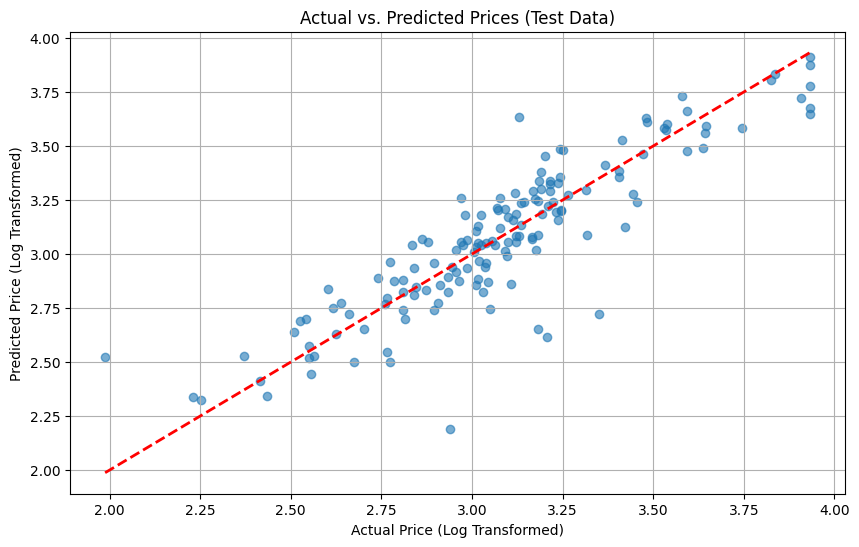

In [118]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6)
plt.xlabel('Actual Price (Log Transformed)')
plt.ylabel('Predicted Price (Log Transformed)')
plt.title('Actual vs. Predicted Prices (Test Data)')

min_val = min(y_test.min(), y_pred_test.min())
max_val = max(y_test.max(), y_pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
plt.grid(True)
plt.show()

In [123]:
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [142]:
def predict():
  feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

  feature_ranges = {
      'CRIM': {'min': 0.00632, 'max': 88.9762},
      'ZN': {'min': 0.0, 'max': 100.0},
      'INDUS': {'min': 0.46, 'max': 27.74},
      'CHAS': {'min': 0, 'max': 1},
      'NOX': {'min': 0.385, 'max': 0.871},
      'RM': {'min': 3.561, 'max': 8.78},
      'AGE': {'min': 2.9, 'max': 100.0},
      'DIS': {'min': 1.1296, 'max': 12.1265},
      'RAD': {'min': 1.0, 'max': 24.0},
      'TAX': {'min': 187.0, 'max': 711.0},
      'PTRATIO': {'min': 12.6, 'max': 22.0},
      'B': {'min': 0.32, 'max': 396.90},
      'LSTAT': {'min': 1.73, 'max': 37.97}
  }

  validated_inputs = {}

  for feature in feature_names:
      while True:
          user_input = input(f"Enter value for {feature} (between {feature_ranges[feature]['min']} and {feature_ranges[feature]['max']}): ")
          try:
              value = float(user_input)

              if feature == 'CHAS':
                  if value not in [0, 1]:
                      print('CHAS must be 0 or 1.')
                      continue

              if not (feature_ranges[feature]['min'] <= value <= feature_ranges[feature]['max']):
                  print(f"Input for {feature} must be between {feature_ranges[feature]['min']} and {feature_ranges[feature]['max']}.")
                  continue

              validated_inputs[feature] = value
              break
          except ValueError:
              print('Invalid input. Please enter a numeric value.')


  new_property_data = pd.DataFrame({
      'CRIM': [validated_inputs['CRIM']],
      'ZN': [validated_inputs['ZN']],
      'INDUS': [validated_inputs['INDUS']],
      'CHAS': [validated_inputs['CHAS']],
      'NOX': [validated_inputs['NOX']],
      'RM': [validated_inputs['RM']],
      'AGE': [validated_inputs['AGE']],
      'DIS': [validated_inputs['DIS']],
      'RAD': [validated_inputs['RAD']],
      'TAX': [validated_inputs['TAX']],
      'PTRATIO': [validated_inputs['PTRATIO']],
      'B': [validated_inputs['B']],
      'LSTAT': [validated_inputs['LSTAT']]
  })

  skewed_features = ['CRIM', 'ZN', 'NOX', 'RAD', 'TAX', 'B', 'LSTAT']
  for feature in skewed_features:
      new_property_data[feature] = np.log1p(new_property_data[feature])

  predicted_log_price = lr.predict(new_property_data)
  estimated_price = np.expm1(predicted_log_price[0])

  print(f"Estimated price for the property: ${estimated_price * 1000:.2f}")

In [144]:
predict()

Enter value for CRIM (between 0.00632 and 88.9762): o
Invalid input. Please enter a numeric value.
Enter value for CRIM (between 0.00632 and 88.9762): 0.3
Enter value for ZN (between 0.0 and 100.0): 67
Enter value for INDUS (between 0.46 and 27.74): 2
Enter value for CHAS (between 0 and 1): 64
CHAS must be 0 or 1.
Enter value for CHAS (between 0 and 1): 1
Enter value for NOX (between 0.385 and 0.871): 5
Input for NOX must be between 0.385 and 0.871.
Enter value for NOX (between 0.385 and 0.871): 0.45
Enter value for RM (between 3.561 and 8.78): 124
Input for RM must be between 3.561 and 8.78.
Enter value for RM (between 3.561 and 8.78): 2356
Input for RM must be between 3.561 and 8.78.
Enter value for RM (between 3.561 and 8.78): 7
Enter value for AGE (between 2.9 and 100.0): 100
Enter value for DIS (between 1.1296 and 12.1265): 75
Input for DIS must be between 1.1296 and 12.1265.
Enter value for DIS (between 1.1296 and 12.1265): 6
Enter value for RAD (between 1.0 and 24.0): 3
Enter va